# Setup

In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from astropy import constants as const, units as u

In [2]:
import sys
sys.path.append('../')

In [3]:
from functions import M_mono_FM_FT, M_chirp_FM_FT, PSD_1s_fromFT

In [4]:
plt.rcParams['font.family']      = 'serif'
plt.rcParams['font.serif']       = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'  # <--- default: dejavusans

In [5]:
def tick_label_writer(nlist):
    labellist = []
    for n in nlist:
        if n < 0:
            if n == -1:
                labellist += [r'-$f_m$']
            else:
                labellist += [r'{0}$f_m$'.format(n)]
        if n == 0:
            labellist += [r'$f_c$']
        if n > 0:
            if n == 1:
                labellist += [r'+$f_m$']
            else:
                labellist += [r'+{0}$f_m$'.format(n)]
    return labellist

# Calculations (Figure 6)

In [6]:
# Model parameters for the input signals

A       = 1
fc      = 1
fm      = 0.05
dfprime = 0.000004
phi0    = 0
phip    = 0
t0      = 0

In [7]:
# Observation and timing information
Tobs = 4000
df   = 1/Tobs

fs   = 6
fNy  = fs/2

In [8]:
# frequencies
freqs_full = np.arange(df, fNy+df, df) * (1+1e-15)
freqs_zoom = np.arange(fc-6*fm, fc+6*fm, df) * (1+1e-15)

In [9]:
# Phase modulation index parameters
ep1 = 0.1
ep2 = 0.3
ep3 = 2

In [10]:
# Number of terms to include in the series calculation
Nterms = 20

In [11]:
# Monochromatic Signals (Fourier Transform and PSD)
signal_mono_FM_full = M_mono_FM_FT(A, fc, fm, ep1, phi0, phip, t0, freqs_full, Tobs, Nterms)
PSD_mono_FM_full    = PSD_1s_fromFT(signal_mono_FM_full, Tobs).real

signal_mono_FM_zoom = M_mono_FM_FT(A, fc, fm, ep1, phi0, phip, t0, freqs_zoom, Tobs, Nterms)
PSD_mono_FM_zoom    = PSD_1s_fromFT(signal_mono_FM_zoom, Tobs).real

signal_mono_FM_zoom2 = M_mono_FM_FT(A, fc, fm, ep2, phi0, phip, t0, freqs_zoom, Tobs, Nterms)
PSD_mono_FM_zoom2    = PSD_1s_fromFT(signal_mono_FM_zoom2, Tobs).real

signal_mono_FM_zoom3 = M_mono_FM_FT(A, fc, fm, ep3, phi0, phip, t0, freqs_zoom, Tobs, Nterms)
PSD_mono_FM_zoom3    = PSD_1s_fromFT(signal_mono_FM_zoom3, Tobs).real

In [12]:
signal_mono_noMod_zoom = M_mono_FM_FT(A, fc, 0, 0, phi0, phip, t0, freqs_zoom, Tobs, 0)
PSD_mono_noMod_zoom    = PSD_1s_fromFT(signal_mono_noMod_zoom, Tobs).real

In [13]:
# Phase Chirping Signals (Fourier Transform and PSD)
signal_chirp_FM_zoom = M_chirp_FM_FT(A, fc, fm, dfprime, ep1, phi0, phip, t0, freqs_zoom, Tobs, Nterms)
PSD_chirp_FM_zoom    = PSD_1s_fromFT(signal_chirp_FM_zoom, Tobs).real

signal_chirp_FM_zoom2 = M_chirp_FM_FT(A, fc, fm, dfprime, ep2, phi0, phip, t0, freqs_zoom, Tobs, Nterms)
PSD_chirp_FM_zoom2    = PSD_1s_fromFT(signal_chirp_FM_zoom2, Tobs).real

signal_chirp_FM_zoom3 = M_chirp_FM_FT(A, fc, fm, dfprime, ep3, phi0, phip, t0, freqs_zoom, Tobs, Nterms)
PSD_chirp_FM_zoom3    = PSD_1s_fromFT(signal_chirp_FM_zoom3, Tobs).real

In [14]:
signal_chirp_noMod_zoom = M_chirp_FM_FT(A, fc, 0, dfprime, 0, phi0, phip, t0, freqs_zoom, Tobs, 0)
PSD_chirp_noMod_zoom    = PSD_1s_fromFT(signal_chirp_noMod_zoom, Tobs).real

# Figure 6

In [15]:
color_ep0 = 'k'
color_ep1 = '#4b026c'   # dark purple
color_ep2 = '#ef432d'   # red-orange
color_ep3 = '#ffa700'   # orange

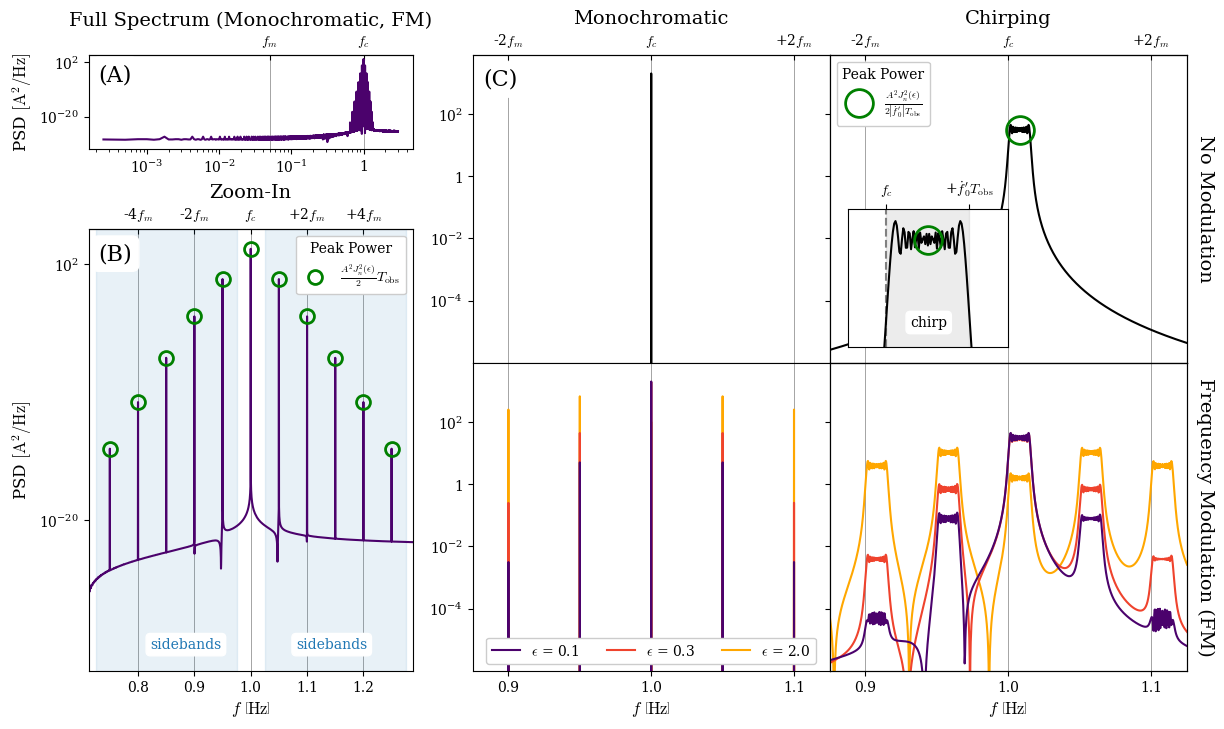

In [16]:
fig = plt.figure(figsize=(12,8))

gs1 = GridSpec(4, 1, left=0.06, right=0.33, hspace=0.85)
ax1_t = fig.add_subplot(gs1[0, 0])
ax1_b = fig.add_subplot(gs1[1:, 0], sharey=ax1_t)

gs2 = GridSpec(4, 2, left=0.38, right=0.975, hspace=0, wspace=0)
ax2_tl = fig.add_subplot(gs2[0:2, 0])
ax2_tr = fig.add_subplot(gs2[0:2, 1], sharex=ax2_tl, sharey=ax2_tl)
ax2_bl = fig.add_subplot(gs2[2:,  0], sharex=ax2_tl, sharey=ax2_tl)
ax2_br = fig.add_subplot(gs2[2:,  1], sharex=ax2_tl, sharey=ax2_tl)


#--------------------- 1: Top + Bottom -----------------------------------------
ax1_t.loglog(freqs_full, PSD_mono_FM_full,   color=color_ep1)
ax1_b.semilogy(freqs_zoom, PSD_mono_FM_zoom, color=color_ep1)

ax1_t2 = ax1_t.secondary_xaxis('top')
ax1_t2.tick_params(direction="in")
ax1_t2.set_xticks([fc, fm]), ax1_t2.set_xticklabels(['$f_c$', '$f_m$'])
ax1_t2.minorticks_off()
for val in [fc, fm]:
    ax1_t.axvline(val, color='gray', linewidth=0.5, zorder=0)

ax1_b.axvspan(fc - 5.5*fm, fc - 0.5*fm, color='C0', alpha=0.1)
ax1_b.axvspan(fc + 0.5*fm, fc + 5.5*fm, color='C0', alpha=0.1)
ax1_b.text(0.5-0.31,0.05, 'sidebands', fontsize=10, color='C0', transform=ax1_b.transAxes, bbox=dict(boxstyle='round,pad=0.3',alpha=1,color='white'));
ax1_b.text(0.5+0.14,0.05, 'sidebands', fontsize=10, color='C0', transform=ax1_b.transAxes, bbox=dict(boxstyle='round,pad=0.3',alpha=1,color='white'));

ax1_b2 = ax1_b.secondary_xaxis('top')
ax1_b2.tick_params(direction="in")
n_ticks = [-4,-2,0,2,4]
ax_tick_list       = [fc + n*fm for n in n_ticks]
x_tick_list_labels = tick_label_writer(n_ticks)
ax1_b2.set_xticks(ax_tick_list), ax1_b2.set_xticklabels(x_tick_list_labels)
for val in ax_tick_list:
    ax1_b.axvline(val, color='gray', linewidth=0.5, zorder=0)

ax1_b.set_xticks(ax_tick_list)

ax1_b.plot(fc + 0 * fm, A**2*sp.jv(0,ep1)**2/2*Tobs, color='g', marker='o', fillstyle='none', linestyle='none', markersize=10, markeredgewidth=2, label=r'$\frac{A^2 J_n^2(\epsilon)}{2}T_\mathrm{obs}$')
for i in [i for i in range(1,5+1)] + [-i for i in range(1,5+1)]:
    ax1_b.plot(fc + i * fm, A**2*sp.jv(i,ep1)**2/2*Tobs, color='g', marker='o', fillstyle='none', markersize=10, markeredgewidth=2)
ax1_b.legend(loc='upper right', title='Peak Power', framealpha=1)


#-------------------- 2: LEFT / Top + Bottom ------------------------------------------
ax2_tl.semilogy(freqs_zoom, PSD_mono_noMod_zoom, color=color_ep0)
ax2_bl.semilogy(freqs_zoom, PSD_mono_FM_zoom,    color=color_ep1, zorder=3, label=r'$\epsilon$ = {0:0.1f}'.format(ep1))
ax2_bl.semilogy(freqs_zoom, PSD_mono_FM_zoom2,   color=color_ep2, zorder=2, label=r'$\epsilon$ = {0:0.1f}'.format(ep2))
ax2_bl.semilogy(freqs_zoom, PSD_mono_FM_zoom3,   color=color_ep3, zorder=1, label=r'$\epsilon$ = {0:0.1f}'.format(ep3))

ax2_tl2 = ax2_tl.secondary_xaxis('top')
ax2_tl2.tick_params(direction="in")
n_ticks = [-2,0,2]
ax_tick_list       = [fc + n*fm for n in n_ticks]
x_tick_list_labels = tick_label_writer(n_ticks)
ax2_tl2.set_xticks(ax_tick_list), ax2_tl2.set_xticklabels(x_tick_list_labels)
for val in ax_tick_list:
    ax2_tl.axvline(val, color='gray', linewidth=0.5, zorder=0)
    ax2_bl.axvline(val, color='gray', linewidth=0.5, zorder=0)

ax2_bl.legend(loc='lower center', ncols=3, framealpha=1)


#-------------------- 2: RIGHT / Top + Bottom ------------------------------------------
ax2_tr.semilogy(freqs_zoom, PSD_chirp_noMod_zoom, color=color_ep0)
ax2_br.semilogy(freqs_zoom, PSD_chirp_FM_zoom,    color=color_ep1,  zorder=3)
ax2_br.semilogy(freqs_zoom, PSD_chirp_FM_zoom2,   color=color_ep2, zorder=2)
ax2_br.semilogy(freqs_zoom, PSD_chirp_FM_zoom3,   color=color_ep3, zorder=1)

ax2_tr2 = ax2_tr.secondary_xaxis('top')
ax2_tr2.tick_params(direction="in")
n_ticks = [-2,0,2]
ax_tick_list       = [fc + n*fm for n in n_ticks]
x_tick_list_labels = tick_label_writer(n_ticks)
ax2_tr2.set_xticks(ax_tick_list), ax2_tr2.set_xticklabels(x_tick_list_labels)
for val in ax_tick_list:
    ax2_tr.axvline(val, color='gray', linewidth=0.5, zorder=0)
    ax2_br.axvline(val, color='gray', linewidth=0.5, zorder=0)

ax2_tr.plot(fc + dfprime*Tobs/2, A**2/(2*np.abs(dfprime)*Tobs), color='g', marker='o', fillstyle='none', linestyle='none', markersize=20, markeredgewidth=2, label=r'$\frac{A^2 J_n^2(\epsilon)}{2 \left|\dot{f}^{\prime}_0\right| T_\mathrm{obs}}$')
ax2_tr.legend(loc='upper left', title='Peak Power', framealpha=1)


#--------------------------------------------------------------
# Create the inset graph
axins = ax2_tr.inset_axes([0.05, 0.05, 0.45, 0.45], xlim=(fc + dfprime*Tobs/2 - fm, fc + dfprime*Tobs/2 + fm)) # <--[x0, y0, width, height]
axins.semilogy(freqs_zoom, PSD_chirp_noMod_zoom, color=color_ep0)
axins.axvline(fc, color='gray', linestyle='--', zorder=1)
axins.axvspan(fc, fc + dfprime*Tobs, color='gray', alpha=0.15);
axins.plot(fc + dfprime*Tobs/2, A**2/(2*np.abs(dfprime)*Tobs), color='g', marker='o', fillstyle='none', linestyle='none', markersize=20, markeredgewidth=2)

axins.set_xticks([fc, fc+dfprime*Tobs]), axins.set_xticklabels(['$f_c$', r'+$\dot{f}^{\prime}_0 T_\mathrm{obs}$']), axins.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axins.set_yticks([]); axins.minorticks_off(); 
axins.text(0.39,0.15, 'chirp', fontsize=10, color='k', transform=axins.transAxes, bbox=dict(boxstyle='round,pad=0.3',alpha=1,color='white'));


#--------------------------------------------------------------
ax1_b.minorticks_off()
ax2_bl.minorticks_off()
ax2_tr.tick_params(left=False, labelleft=False)
ax2_br.tick_params(left=False, labelleft=False)

#--------------------------------------------------------------
ax1_t.set_title('Full Spectrum (Monochromatic, FM)', fontsize=14); ax1_b.set_title('Zoom-In', fontsize=14);
ax2_tl.set_title('Monochromatic', fontsize=14); ax2_tr.set_title('Chirping', fontsize=14);
ax2_tr2 = ax2_tr.twinx()
ax2_tr2.set_ylabel('No Modulation', fontsize=14, labelpad=20, rotation=-90), ax2_tr2.tick_params(right=False, labelright=False)
ax2_br2 = ax2_br.twinx()
ax2_br2.set_ylabel('Frequency Modulation (FM)', fontsize=14, labelpad=20, rotation=-90), ax2_br2.tick_params(right=False, labelright=False)


#--------------------------------------------------------------
ax1_b.set_xlim([fc - 5.75*fm, fc + 5.75*fm])
ax2_tl.set_xlim([fc - 2.5*fm, fc + 2.5*fm])
ax2_tl.set_ylim([1e-6, A**2/2*Tobs*4])
axins.set_xlim([fc-0.15*fm,fc+dfprime*Tobs+0.15*fm]), axins.set_ylim([4e0,A**2/(2*np.abs(dfprime)*Tobs)*1.8])

ax1_t.set_yticks([1e-20, 1e2])
ax2_tl.set_xticks(ax_tick_list)
ax2_tl.set_yticks([1e-4, 1e-2, 1e0, 1e2]), ax2_tl.set_yticklabels(['$\\mathdefault{10^{-4}}$','$\\mathdefault{10^{-2}}$','$\\mathdefault{1}$','$\\mathdefault{10^{2}}$'])

ax1_t.set_ylabel(r'PSD $\left[\text{A}^2/\text{Hz}\right]$', fontsize=12), ax1_b.set_ylabel(r'PSD $\left[\text{A}^2/\text{Hz}\right]$', fontsize=12)
ax1_b.set_xlabel(r'$f \ \left[\text{Hz}\right]$', fontsize=12), ax2_bl.set_xlabel(r'$f \ \left[\text{Hz}\right]$', fontsize=12), ax2_br.set_xlabel(r'$f \ \left[\text{Hz}\right]$', fontsize=12)

ax1_t.text(0.03,0.72, '(A)', fontsize=16, color='k', transform=ax1_t.transAxes, bbox=dict(boxstyle='round,pad=0.3',alpha=1,color='white'));
ax1_b.text(0.03,0.93, '(B)', fontsize=16, color='k', transform=ax1_b.transAxes, bbox=dict(boxstyle='round,pad=0.3',alpha=1,color='white'));
ax2_tl.text(0.03,0.90, '(C)', fontsize=16, color='k', transform=ax2_tl.transAxes, bbox=dict(boxstyle='round,pad=0.3',alpha=1,color='white'));

ax1_t.set_xticks([1e-3, 1e-2, 1e-1, 1]), ax1_t.set_xticklabels(['$\\mathdefault{10^{-3}}$','$\\mathdefault{10^{-2}}$','$\\mathdefault{10^{-1}}$','$\\mathdefault{1}$'])


plt.show()
# plt.savefig('./spectral_features.pdf')

# Calculations (Figure 7)

In [17]:
# Observation time
Tobs2 = 18000

In [18]:
# frequencies
freqs = np.arange(fc-20*fm, fc+20*fm, df)

In [19]:
fc2, dfprime2 = 0.97, 2e-6
dfprime_text, dfprime2_text = r'$4\times10^{-6}$', r'$2\times10^{-6}$'

# Phase Chirping Signals (Fourier Transform and PSD)
signal1 = M_chirp_FM_FT(A, fc, fm, dfprime, ep2, phi0, phip, t0, freqs, Tobs, Nterms)
PSD1    = PSD_1s_fromFT(signal1, Tobs).real

signal2 = M_chirp_FM_FT(A, fc2, 0, dfprime2, 0, phi0, phip, t0, freqs, Tobs, Nterms)
PSD2    = PSD_1s_fromFT(signal2, Tobs).real

total1    = signal1 + signal2
PSDtotal1 = PSD_1s_fromFT(total1, Tobs).real

signal1_2 = M_chirp_FM_FT(A, fc, fm, dfprime, ep2, phi0, phip, t0, freqs, Tobs2, Nterms)
PSD1_2    = PSD_1s_fromFT(signal1_2, Tobs).real

signal2_2 = M_chirp_FM_FT(A, fc2, 0, dfprime2, 0, phi0, phip, t0, freqs, Tobs2, Nterms)
PSD2_2    = PSD_1s_fromFT(signal2_2, Tobs).real

total2    = signal1_2 + signal2_2
PSDtotal2 = PSD_1s_fromFT(total2, Tobs).real

# Figure 7

In [20]:
alpha_total = 1
alpha_sig   = 0.7
alpha_chirp = 0.1
color1 = '#4b026c'   # dark purple
color2 = '#ffa700'   # orange

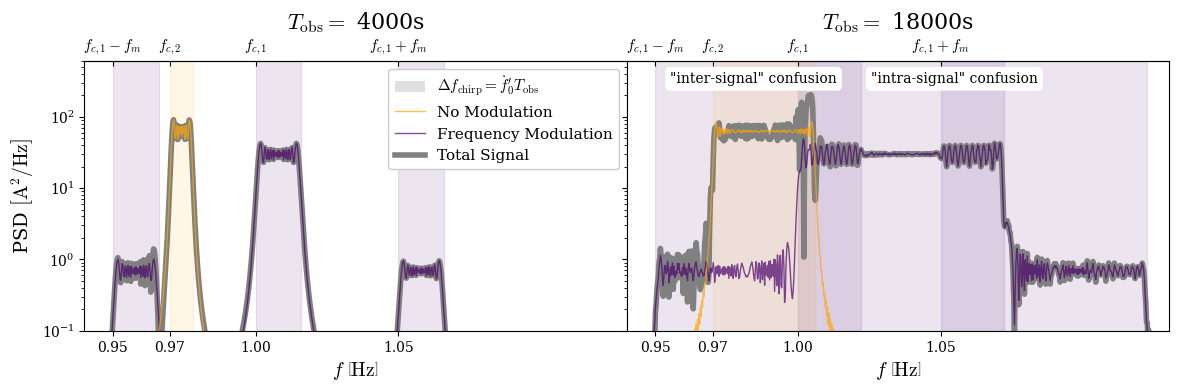

In [21]:
fig, ax = plt.subplots(1,2,figsize=(14,3.5), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.0)

#----------------------------------------------------------------------------------------------------
ax[0].semilogy(freqs, PSDtotal1, linewidth=4, color='gray', alpha=alpha_total)
ax[0].semilogy(freqs, PSD1,      linewidth=1, color=color1, alpha=alpha_sig)
ax[0].semilogy(freqs, PSD2,      linewidth=1, color=color2, alpha=alpha_sig)

#----------------------------------------------------------------------------------------------------
ax[1].semilogy(freqs, PSDtotal2, linewidth=4, color='gray', alpha=alpha_total)
ax[1].semilogy(freqs, PSD1_2,    linewidth=1, color=color1, alpha=alpha_sig)
ax[1].semilogy(freqs, PSD2_2,    linewidth=1, color=color2, alpha=alpha_sig)

#----------------------------------------------------------------------------------------------------
ax[0].axvspan(fc,    fc+dfprime*Tobs,    color=color1, alpha=alpha_chirp), ax[1].axvspan(fc,    fc+dfprime*Tobs2,    color=color1, alpha=alpha_chirp);
ax[0].axvspan(fc-fm, fc-fm+dfprime*Tobs, color=color1, alpha=alpha_chirp), ax[1].axvspan(fc-fm, fc-fm+dfprime*Tobs2, color=color1, alpha=alpha_chirp);
ax[0].axvspan(fc+fm, fc+fm+dfprime*Tobs, color=color1, alpha=alpha_chirp), ax[1].axvspan(fc+fm, fc+fm+dfprime*Tobs2, color=color1, alpha=alpha_chirp);
ax[0].axvspan(fc2,   fc2+dfprime2*Tobs,  color=color2, alpha=alpha_chirp), ax[1].axvspan(fc2,   fc2+dfprime2*Tobs2,  color=color2, alpha=alpha_chirp);

#----------------------------------------------------------------------------------------------------
ax[0].set_title(r'$T_\mathrm{{obs}} = $ {0:0.0f}s'.format(Tobs), fontsize=16), ax[1].set_title(r'$T_\mathrm{{obs}} = $ {0:0.0f}s'.format(Tobs2), fontsize=16)
ax[0].set_xlabel(r'$f \ \left[\text{Hz}\right]$', fontsize=14), ax[1].set_xlabel(r'$f \ \left[\text{Hz}\right]$', fontsize=14)
ax[0].set_ylabel(r'PSD $\left[\text{A}^2/\text{Hz}\right]$', fontsize=14)

ax0t = ax[0].secondary_xaxis('top')
ax0t.tick_params(direction="in"), ax0t.minorticks_off()
ax0t.set_xticks([fc2, fc, fc-fm, fc+fm]), ax0t.set_xticklabels(['$f_{c,2}$', '$f_{c,1}$', '$f_{c,1}-f_m$', '$f_{c,1}+f_m$'], fontsize=11)

ax1t = ax[1].secondary_xaxis('top')
ax1t.tick_params(direction="in"), ax1t.minorticks_off()
ax1t.set_xticks([fc2, fc, fc-fm, fc+fm]), ax1t.set_xticklabels(['$f_{c,2}$', '$f_{c,1}$', '$f_{c,1}-f_m$', '$f_{c,1}+f_m$'], fontsize=11)

legend_custom = [Patch(facecolor='gray', alpha=0.25, label=r'$\Delta f_\mathrm{chirp} = \dot{f}^{\prime}_0 T_\mathrm{obs}$'),
                 Line2D([0], [0], color=color2, linestyle='-', lw=1, alpha=alpha_sig,   label='No Modulation'),
                 Line2D([0], [0], color=color1, linestyle='-', lw=1, alpha=alpha_sig,   label='Frequency Modulation'),
                 Line2D([0], [0], color='gray', linestyle='-', lw=4, alpha=alpha_total, label='Total Signal')
                ]
ax[0].legend(handles=legend_custom, loc='upper right', framealpha=1, fontsize=11)

ax[1].text(0.45,0.92, '"intra-signal" confusion', fontsize=10, color='k', transform=ax[1].transAxes, bbox=dict(boxstyle='round,pad=0.3',alpha=1,color='white'));
ax[1].text(0.08,0.92, '"inter-signal" confusion', fontsize=10, color='k', transform=ax[1].transAxes, bbox=dict(boxstyle='round,pad=0.3',alpha=1,color='white'));


ax[0].set_xticks([fc2, fc, fc-fm, fc+fm])
ax[0].set_xlim([0.94,1.13]), ax[0].set_ylim(bottom=1e-1, top=6e2)

plt.show()
# plt.savefig('./inter-intra_signal_confusion.pdf', bbox_inches='tight')